# Proyecto de Clasificación Multiclase: Estimación de Niveles de Obesidad

Este proyecto surge en el marco de la salud preventiva, utilizando el Machine Learning para clasificar niveles de obesidad basados en hábitos alimenticios y condición física.

El objetivo principal es desarrollar un modelo capaz de predecir con precisión una de las 7 categorías de peso (desde Peso Insuficiente hasta Obesidad Tipo III). Este es un problema de clasificación multiclase donde buscaremos no solo la precisión global, sino un equilibrio en las métricas por clase y un overfitting controlado inferior al 5%.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [2]:
data = pd.read_csv("../data/raw/ObesityDataSet.csv")
df = data.copy()

In [7]:
print(f"El dataset contiene {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head(10)

El dataset contiene 2111 registros y 17 columnas.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [6]:
df.shape

(2111, 17)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [10]:
print(df.isnull().sum())
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Número de filas duplicadas: 24


In [11]:
# Filtramos el dataframe para ver solo las filas que tienen duplicados
duplicados_df = df[df.duplicated(keep=False)]

# Ordenamos por alguna columna (ej: Age) para ver las copias juntas
duplicados_df.sort_values(by='Age').head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
443,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I


Se ha identificado la presencia de 24 registros duplicados en el conjunto de datos original. Tras un análisis visual de estas filas, se ha tomado la decisión estratégica de eliminarlas basándonos en los siguientes pilares de ciencia de datos:

Prevención de Fuga de Datos (Data Leakage):  Al trabajar con modelos de Machine Learning, es crítico asegurar que el modelo no "memorice" ejemplos exactos. Si un registro duplicado aparece tanto en el conjunto de entrenamiento como en el de prueba, las métricas de evaluación (como el Accuracy) serían artificialmente altas y poco realistas.

Mitigación de Sesgos por Datos Sintéticos:  Dado que este dataset contiene datos generados mediante algoritmos para equilibrar las clases, la repetición exacta de registros con múltiples decimales sugiere redundancia técnica más que variabilidad biológica real.

Control del Overfitting:  Eliminar estas redundancias es el primer paso para cumplir con el requisito del proyecto de mantener un overfitting inferior al 5%, obligando al modelo a aprender patrones generales de salud en lugar de casos específicos repetidos.

In [12]:
df.drop_duplicates(inplace=True)
print(f"Dimensiones después de eliminar duplicados: {df.shape}")

Dimensiones después de eliminar duplicados: (2087, 17)


In [14]:
# Estadísticas para Edad, Peso, Altura, etc.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353090,6.368801,14.00,19.915937,22.847618,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
FCVC,2087.0,2.421466,0.534737,1.00,2.000000,2.396265,3.000000,3.00
NCP,2087.0,2.701179,0.764614,1.00,2.697467,3.000000,3.000000,4.00
CH2O,2087.0,2.004749,0.608284,1.00,1.590922,2.000000,2.466193,3.00
FAF,2087.0,1.012812,0.853475,0.00,0.124505,1.000000,1.678102,3.00
TUE,2087.0,0.663035,0.608153,0.00,0.000000,0.630866,1.000000,2.00


In [15]:
# Estadísticas para Género, Historial Familiar, Fumador, etc.
df.describe(include=['object']).T

C:\Users\gemit\AppData\Local\Temp\ipykernel_3800\985510633.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object']).T


,count,unique,top,freq
Gender,2087,2,Male,1052
family_history_with_overweight,2087,2,yes,1722
FAVC,2087,2,yes,1844
CAEC,2087,4,Sometimes,1761
SMOKE,2087,2,no,2043
SCC,2087,2,no,1991
CALC,2087,4,Sometimes,1380
MTRANS,2087,5,Public_Transportation,1558
NObeyesdad,2087,7,Obesity_Type_I,351


# Análisis del Target: Balance de Clases
Para evitar que el modelo tenga sesgos, es vital comprobar si tenemos suficientes ejemplos de cada nivel de obesidad.

C:\Users\gemit\AppData\Local\Temp\ipykernel_3800\763601157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='NObeyesdad', data=df, palette='viridis', order=df['NObeyesdad'].value_counts().index)


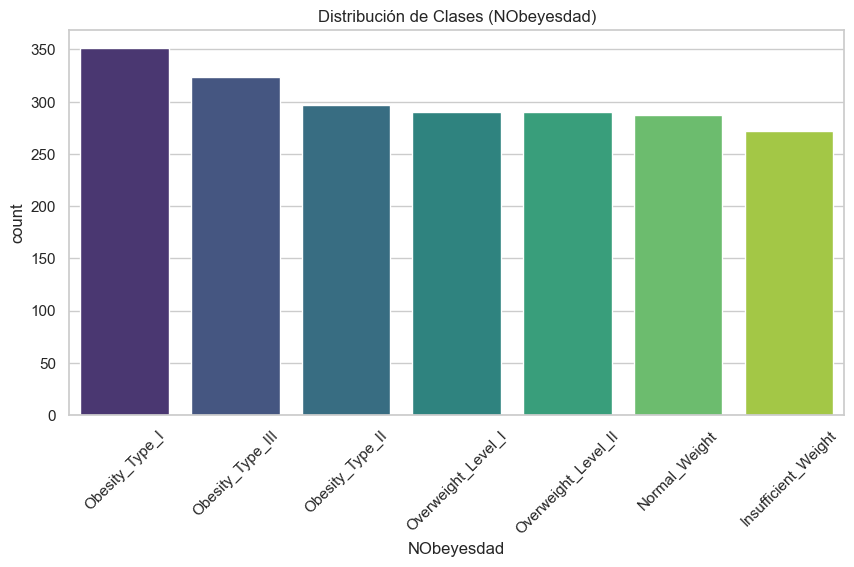

Frecuencia de clases:
 NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(x='NObeyesdad', data=df, palette='viridis', order=df['NObeyesdad'].value_counts().index)
plt.title('Distribución de Clases (NObeyesdad)')
plt.xticks(rotation=45)
plt.show()

print("Frecuencia de clases:\n", df['NObeyesdad'].value_counts(normalize=True) * 100)